# ⏱️ 시간 연속성 기반 전처리 — 측정 주기·리샘플링·결측·보간·파이프라인 핵심 노트

**학습 범위**
- 22_01 측정 주기와 리샘플링 후 결측
- 22_02 누락 시점 처리와 전처리 파이프라인

이번 노트는 단순 요약뿐 아니라 다음을 포함합니다.

- ✅ 핵심 개념과 코드
- ✅ **실제로 실행되는 합성 예제**
- ✅ **그래프와 결과값이 노트북에 미리 출력된 예제**
- ✅ 상황별로 어떤 코드를 쓰는 것이 더 적합한지
- ✅ 보간·리샘플링 시 주의할 점
- ✅ 강의자료에서 확인할 수 없는 부분은 임의로 단정하지 않기

> **중요:** 강의에 사용된 실제 CSV 파일은 이번 첨부에 포함되어 있지 않으므로,  
> 실행 그래프는 개념을 재현하기 위해 만든 **합성 데모 데이터**입니다.  
> 강의자료의 실제 결과와 합성 데모 결과는 노트 안에서 명확히 구분합니다.

In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 1. 📌 한 줄 요약 (Executive Summary)

현실의 설비 센서 데이터는 측정 시각이 정확히 일정하지 않고 중간 시점이 빠질 수 있으므로, 분석 전에 먼저 **시간 축을 일정한 격자로 정리하고 결측의 위치·길이를 확인한 뒤 센서 성격에 맞게 복원**해야 합니다.

핵심 흐름:

```text
timestamp 변환
→ 시간 인덱스
→ 시간순 정렬
→ 측정 간격 진단
→ asfreq / resample 선택
→ 결측 개수·비율·위치 확인
→ ffill / bfill / interpolate 선택
→ 긴 결측 제한
→ 전후 그래프 검증
→ 분석 투입
```

## 2. 🗂️ 핵심 목차

- **A. 시간 연속성이 왜 중요한가**
- **B. 시간 인덱스 3단계**
- **C. 측정 주기 진단**
- **D. `asfreq`와 `resample` 선택**
- **E. 리샘플링 후 NaN의 의미**
- **F. 결측 개수·비율·위치·연속 길이**
- **G. `ffill` / `bfill`**
- **H. 선형 보간 / 시간 보간**
- **I. 긴 결측과 `limit`**
- **J. 보간 전후 그래프 검증**
- **K. 상황별 추천 코드**
- **L. 전처리 파이프라인**
- **M. 품질 점검 체크리스트**
- **N. 셀프 체크 퀴즈**

## 3. 💻 한눈에 보는 코드 정리

| 상황 | 추천 코드 | 왜 사용하는가 | 주의 |
|---|---|---|---|
| 문자열 시간을 시간형으로 | `pd.to_datetime()` | 시간 계산 가능 | 변환 실패값 점검 필요 |
| 시간 인덱스 만들기 | `set_index().sort_index()` | 시계열 기능 기반 | 정렬과 일정 간격은 다른 개념 |
| 실제 측정 간격 진단 | `index.to_series().diff()` | 간격이 일정한지 확인 | 첫 값은 NaT/NaN |
| 간격 분포 확인 | `.dt.total_seconds().value_counts()` | 기준 주기 후보 파악 | 가장 흔한 값이 항상 정답인 것은 아님 |
| 원본을 격자에 그대로 배치 | `.asfreq("10s")` | 빠진 시점 드러내기 | 격자와 안 맞는 시각의 값은 사용되지 않을 수 있음 |
| 구간 대표값으로 묶기 | `.resample("1min").mean()` | 다운샘플링·노이즈 감소 | 짧은 피크가 평균에 묻힐 수 있음 |
| 짧은 상태값 결측 | `.ffill()` | 앞 상태 유지 | 상승·하락 추세를 계단처럼 만들 수 있음 |
| 앞부분 결측 보완 | `.bfill()` | 뒤 실제값 사용 | 미래값을 과거에 복사한다는 의미 고려 |
| 연속형 센서 보간 | `.interpolate()` | 앞뒤 값 사이 추정 | 긴 공백은 신뢰 낮음 |
| 불규칙 시간 간격 보간 | `.interpolate(method="time")` | 실제 시간 간격 반영 | DatetimeIndex 필요 |
| 짧은 공백만 보간 | `interpolate(limit=2)` | 긴 구간 과도 복원 방지 | 남은 NaN은 의도된 결과일 수 있음 |
| 안쪽 공백만 채우기 | `limit_area="inside"` | 양쪽 실제값 사이만 복원 | 시작/끝 결측은 남을 수 있음 |
| 결측 개수 | `.isna().sum()` | 기본 품질 점검 | 개수만으로는 패턴을 알 수 없음 |
| 결측 비율 | `.isna().mean()` | 심각성 비교 | 센서별 비교 시 유용 |
| 다운샘플링 시 피크도 보기 | `.resample(...).max()` | 최대값 보존 관점 | 평균과 목적이 다름 |

## 4. ⚠️ 강의자료 결과와 데모 결과 구분

강의자료에 명시된 실습 예상 결과에는 다음 값들이 있습니다.

- 10초 `asfreq` 정규화 → **200행, 결측 22칸**
- 같은 데이터의 10초 `resample` → **결측 16칸**
- 1분 다운샘플링 → **결측 1칸**
- 결측 비율 → **11%**
- 첫 빈 시각 → **09:02:30**
- 가장 긴 연속 결측 → **10칸**
- `interpolate(limit=2)` → **NaN 13칸 남음**
- 불규칙 작은 예시: 선형 보간 **25**, 시간 보간 **15**

아래 합성 데모는 이 개념을 복습하기 쉽게 일부 구조를 비슷하게 설계했지만,  
**강의에 사용된 실제 CSV를 계산한 결과는 아닙니다.**

# 5. 🧪 실행 가능한 합성 데모 데이터 만들기

실제 강의 CSV가 없어도 그래프와 결과를 직접 볼 수 있도록  
**10초 주기를 기본으로 하지만 일부 시점이 빠지고 몇몇 값은 시각이 약간 어긋난 데이터**를 만듭니다.

합성 데이터의 목적은 다음 상황을 재현하는 것입니다.

- 정상 주기: 대부분 10초
- 일부 시점 완전 누락
- 일부 값은 정확한 10초 격자가 아니라 몇 초 밀려 도착
- 연속 결측 구간 존재
- 두 개의 연속형 센서 존재

In [3]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 10초 격자의 목표 시점 200개
start = pd.Timestamp("2026-08-28 09:00:00")
grid = pd.date_range(start, periods=200, freq="10s")

# 정확한 격자에서 빠질 시점
# 10칸 연속 + 7칸 연속 + 산발 5칸 = 총 22칸
missing_idx = (
    list(range(15, 25)) +
    list(range(70, 77)) +
    [35, 110, 140, 170, 190]
)
missing_idx = sorted(set(missing_idx))

# 일부 빠진 시점은 정확한 격자 대신 3초 늦은 시각에 값이 들어온 것으로 구성
# asfreq에서는 빠져 보이지만 resample 구간에는 포함되는 예시
jitter_idx = [73, 35, 110, 140, 170, 190]

def underlying_values(i):
    # 완만하게 상승하는 연속형 센서 예시
    control = 0.35 + 0.0022 * i + 0.015 * np.sin(i / 8)
    temp = 780 + 0.16 * i + 1.8 * np.sin(i / 10)
    return control, temp

records = []

for i, t in enumerate(grid):
    if i not in missing_idx:
        control, temp = underlying_values(i)
        records.append({
            "timestamp": t,
            "제어출력": control + np.random.normal(0, 0.004),
            "소입로온도": temp + np.random.normal(0, 0.5),
        })

# 정확한 격자에서는 빠졌지만 약간 늦게 도착한 레코드 6개
for i in jitter_idx:
    t = grid[i] + pd.Timedelta(seconds=3)
    control, temp = underlying_values(i)
    records.append({
        "timestamp": t,
        "제어출력": control + np.random.normal(0, 0.004),
        "소입로온도": temp + np.random.normal(0, 0.5),
    })

raw = (
    pd.DataFrame(records)
    .sort_values("timestamp")
    .reset_index(drop=True)
)

raw["timestamp"] = pd.to_datetime(raw["timestamp"])
raw = raw.set_index("timestamp").sort_index()

print("합성 원본 행 수:", len(raw))
print("측정 시작:", raw.index.min())
print("측정 종료:", raw.index.max())
display(raw.head(8))

합성 원본 행 수: 184
측정 시작: 2026-08-28 09:00:00
측정 종료: 2026-08-28 09:33:10


,제어출력,소입로온도
timestamp,,
2026-08-28 09:00:00,0.351987,779.930868
2026-08-28 09:00:10,0.356661,781.101215
2026-08-28 09:00:20,0.357174,780.560536
2026-08-28 09:00:30,0.368411,781.395654
2026-08-28 09:00:40,0.364113,781.612233
2026-08-28 09:00:50,0.367923,781.430101
2026-08-28 09:01:00,0.374392,781.019716
2026-08-28 09:01:10,0.370013,781.998448


# 6. ⏱️ 측정 간격 진단

## 6-1. 왜 `sort_index()`만으로는 부족한가?

시간순 정렬은:

```text
09:00 → 09:00:10 → 09:01:20
```

처럼 **순서만 맞춰 줍니다.**

하지만 간격이:
- 10초
- 10초
- 70초

처럼 들쭉날쭉할 수 있습니다.

따라서:

> **정렬돼 있다 = 간격이 일정하다**

가 아닙니다.

In [4]:
# 인접한 두 시각의 차이를 초로 변환
sec = raw.index.to_series().diff().dt.total_seconds()

interval_counts = sec.value_counts().sort_index()

print("가장 흔한 간격:")
print(sec.value_counts().head())

print("\n최대 측정 간격:", sec.max(), "초")

가장 흔한 간격:
timestamp
10.0     170
13.0       5
7.0        5
110.0      1
43.0       1
Name: count, dtype: int64

최대 측정 간격: 110.0 초


## 6-2. 측정 간격 분포 그래프

가장 많이 나타나는 간격이 무엇인지 그래프로 보면  
기준 주기 후보를 더 빠르게 파악할 수 있습니다.

> 강의자료에서는 가장 흔한 간격을 기준 주기 후보로 보는 방법을 사용합니다.  
> 다만 실제 현장에서는 설비 설정값이나 수집 시스템 사양도 함께 확인하는 것이 안전합니다.

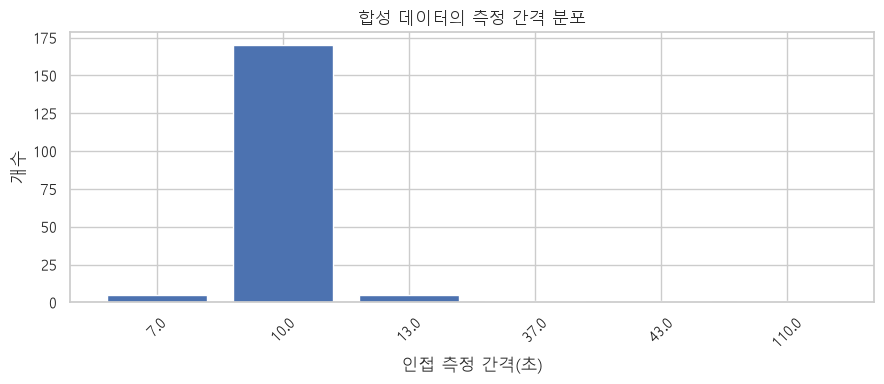

In [5]:
plot_counts = interval_counts[interval_counts.index <= 120]

plt.figure(figsize=(9, 4))
plt.bar(plot_counts.index.astype(str), plot_counts.values)
plt.title("합성 데이터의 측정 간격 분포")
plt.xlabel("인접 측정 간격(초)")
plt.ylabel("개수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. 🧱 `asfreq`와 `resample`

## 7-1. 핵심 차이

### `asfreq`
```python
df.asfreq("10s")
```

- 정해진 시각 격자를 만듦
- 그 시각에 정확히 있는 값을 가져옴
- 합치지 않음
- 없는 칸은 NaN

### `resample`
```python
df.resample("10s").mean()
```

- 10초 **구간**으로 묶음
- 구간 안에 값이 있으면 평균 등 대표값 계산
- 정확히 정각이 아니어도 해당 구간에 들어오면 활용 가능

따라서 두 도구는 **우열이 아니라 목적이 다릅니다.**

In [6]:
as10 = raw[["제어출력", "소입로온도"]].asfreq("10s")
rs10 = raw[["제어출력", "소입로온도"]].resample("10s").mean()
rs1m = raw[["제어출력", "소입로온도"]].resample("1min").mean()

print("[asfreq 10초]")
print("행 수:", len(as10))
print("결측:")
print(as10.isna().sum())

print("\n[resample 10초]")
print("행 수:", len(rs10))
print("결측:")
print(rs10.isna().sum())

print("\n[resample 1분]")
print("행 수:", len(rs1m))
print("결측:")
print(rs1m.isna().sum())

[asfreq 10초]
행 수: 200
결측:
제어출력     22
소입로온도    22
dtype: int64

[resample 10초]
행 수: 200
결측:
제어출력     16
소입로온도    16
dtype: int64

[resample 1분]
행 수: 34
결측:
제어출력     1
소입로온도    1
dtype: int64


### 결과 해석

이 합성 데이터에서는:
- `asfreq("10s")`는 **정확히 10초 격자에 있지 않은 값**을 사용하지 않으므로 결측이 더 많이 드러납니다.
- `resample("10s").mean()`은 같은 10초 구간 안에 몇 초 늦게 들어온 값도 사용할 수 있어 결측이 줄어듭니다.

이 차이는 강의자료에서 설명한  
**“asfreq는 격자 올리기, resample은 구간 묶기”**의 차이입니다.

## 7-2. `asfreq` 정규화 결과 그래프

선이 끊기는 부분이 NaN입니다.

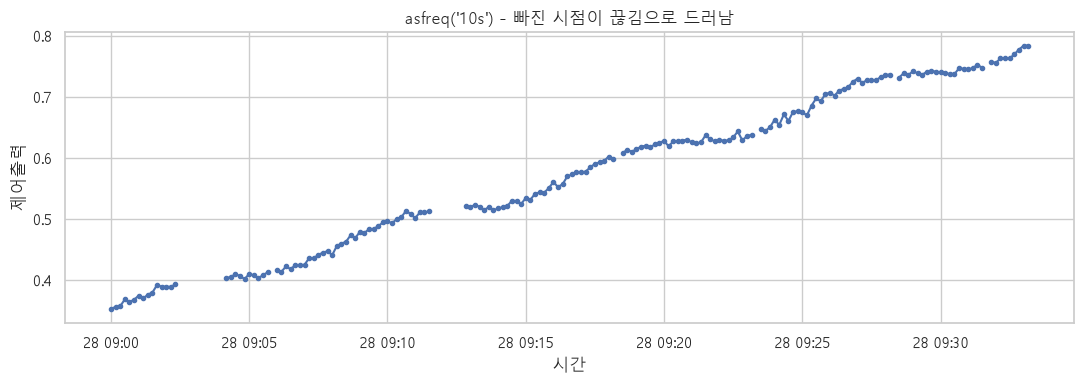

In [7]:
plt.figure(figsize=(11, 4))
plt.plot(as10.index, as10["제어출력"], marker=".")
plt.title("asfreq('10s') - 빠진 시점이 끊김으로 드러남")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.tight_layout()
plt.show()

## 7-3. `resample` 결과 그래프

구간 안에 들어온 값이 대표값으로 사용되므로  
`asfreq`보다 일부 빈 칸이 줄어들 수 있습니다.

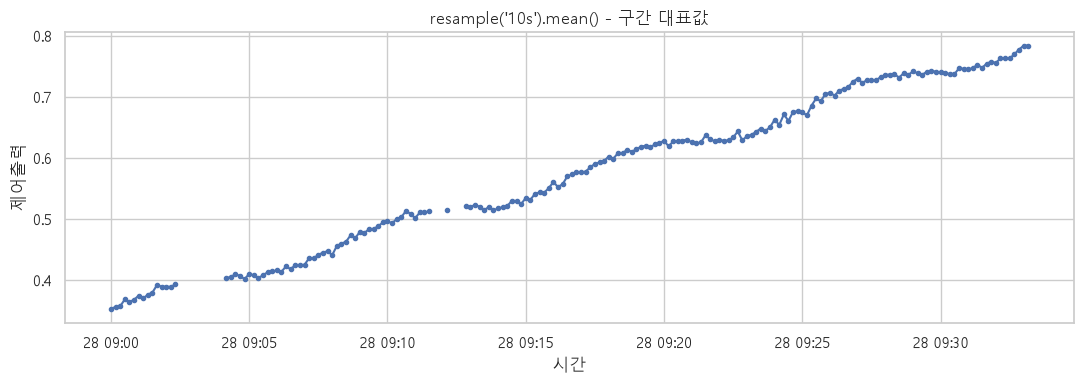

In [8]:
plt.figure(figsize=(11, 4))
plt.plot(rs10.index, rs10["제어출력"], marker=".")
plt.title("resample('10s').mean() - 구간 대표값")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.tight_layout()
plt.show()

# 8. 🎯 상황별 `asfreq` vs `resample` 선택

## `asfreq`가 더 자연스러운 상황
- 정확한 공통 시간 격자를 만들고 싶음
- 원래 값과 결측 위치를 먼저 보고 싶음
- 업샘플링 후 나중에 보간 방법을 결정하고 싶음
- 짧은 이상 신호를 평균으로 뭉개고 싶지 않음

## `resample`이 더 자연스러운 상황
- 여러 값을 1분·10분·1시간 대표값으로 줄이고 싶음
- 장기 추세를 보기 위해 노이즈를 완화하고 싶음
- 다운샘플링이 목적임

### 추가 실무 팁
실제 원본을 보존해야 한다면 원본 DataFrame을 덮어쓰지 않고:

```python
raw = df.copy()
norm = raw.asfreq("10s")
```

처럼 **원본과 정규화 데이터를 따로 보관**하는 편이 안전합니다.

## 8-1. 평균이 항상 적절한 것은 아니다

`resample()` 뒤 집계 함수는 질문에 맞춰 선택합니다.

```python
.mean()  # 구간의 일반 수준
.max()   # 구간의 최대 피크
.min()   # 구간의 최저값
```

예를 들어 **장기 온도 추세**가 목적이면 평균이 자연스럽지만,  
짧은 진동 피크를 놓치면 안 되는 분석에서는 최대값을 함께 보는 것이 더 적합할 수 있습니다.

이는 “항상 max가 더 좋다”는 뜻이 아니라 **분석 목적이 다르다**는 뜻입니다.

In [9]:
summary_1m = raw["제어출력"].resample("1min").agg(["mean", "max", "count"])

display(summary_1m.head(8))

,mean,max,count
timestamp,,,
2026-08-28 09:00:00,0.361045,0.368411,6
2026-08-28 09:01:00,0.380260,0.392097,6
2026-08-28 09:02:00,0.390439,0.393157,3
2026-08-28 09:03:00,NaN,NaN,0
2026-08-28 09:04:00,0.405255,0.409221,5
2026-08-28 09:05:00,0.409395,0.414137,6
2026-08-28 09:06:00,0.419907,0.424941,6
2026-08-28 09:07:00,0.438440,0.447303,6


# 9. 🔍 결측은 개수 → 비율 → 위치 → 연속 길이 순으로 확인

결측 22개라는 숫자만으로는 충분하지 않습니다.

같은 22개라도:

```text
한 칸씩 22번
```

과

```text
22칸 연속
```

은 복원 신뢰도가 완전히 다릅니다.

In [10]:
missing_count = as10.isna().sum()
missing_ratio = as10.isna().mean()

quality = pd.DataFrame({
    "결측 개수": missing_count,
    "결측 비율": missing_ratio
})

display(quality)

,결측 개수,결측 비율
제어출력,22,0.11
소입로온도,22,0.11


In [11]:
# 제어출력의 빈 시각 확인
missing_times = as10.index[as10["제어출력"].isna()]

print("첫 빈 시각:", missing_times[0])
print("빈 시각 개수:", len(missing_times))
print("\n처음 12개 빈 시각:")
print(missing_times[:12])

첫 빈 시각: 2026-08-28 09:02:30
빈 시각 개수: 22

처음 12개 빈 시각:
DatetimeIndex(['2026-08-28 09:02:30', '2026-08-28 09:02:40',
               '2026-08-28 09:02:50', '2026-08-28 09:03:00',
               '2026-08-28 09:03:10', '2026-08-28 09:03:20',
               '2026-08-28 09:03:30', '2026-08-28 09:03:40',
               '2026-08-28 09:03:50', '2026-08-28 09:04:00',
               '2026-08-28 09:05:50', '2026-08-28 09:11:40'],
              dtype='datetime64[us]', name='timestamp', freq=None)


## 9-1. 결측 위치를 0/1 그래프로 보기

`1`인 곳이 결측입니다.  
연속된 1이 길게 이어지면 **연속 결측**입니다.

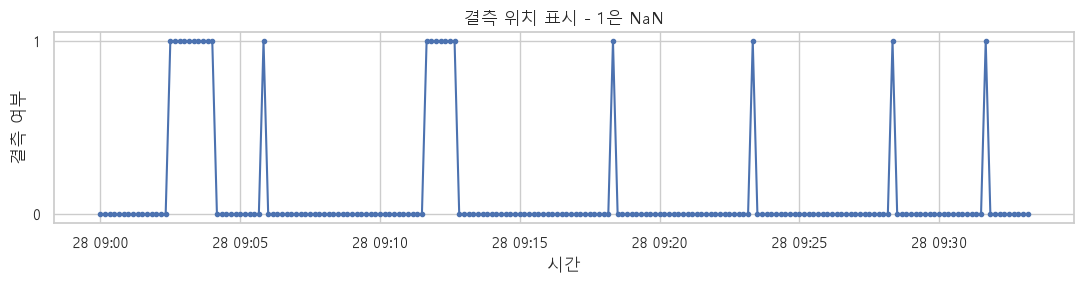

In [12]:
missing_flag = as10["제어출력"].isna().astype(int)

plt.figure(figsize=(11, 3))
plt.plot(missing_flag.index, missing_flag.values, marker=".")
plt.title("결측 위치 표시 - 1은 NaN")
plt.xlabel("시간")
plt.ylabel("결측 여부")
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

## 9-2. 가장 긴 연속 결측 길이 계산

강의자료에서는 결측의 **총 개수뿐 아니라 가장 긴 연속 결측**을 진단 리포트에 포함합니다.

In [13]:
def missing_run_lengths(series):
    mask = series.isna()
    if not mask.any():
        return pd.Series(dtype="int64")
    group = (~mask).cumsum()
    lengths = mask.groupby(group).sum()
    return lengths[lengths > 0].sort_values(ascending=False)

runs = missing_run_lengths(as10["제어출력"])

print("연속 결측 길이들:")
print(runs.tolist())

print("가장 긴 연속 결측:", int(runs.max()), "칸")

연속 결측 길이들:
[10, 7, 1, 1, 1, 1, 1]
가장 긴 연속 결측: 10 칸


# 10. ⚠️ 시계열에서 `dropna()`를 바로 쓰기 어려운 이유

강의자료는 시계열 결측행을 단순 삭제하면:

```text
10초 → 10초 → 10초 → 결측 → 10초
```

가

```text
10초 → 10초 → 20초
```

처럼 다시 불규칙해질 수 있다고 설명합니다.

따라서 **시간 연속성이 중요한 분석**에서는:

```python
dropna()
```

를 결측 개수를 0으로 만드는 단순 해결책처럼 쓰지 않는 것이 중요합니다.

다만 결측 자체가 분석 대상이 아니고 해당 구간을 통째로 제외하는 것이 합리적인 상황에서는 삭제를 검토할 수 있습니다.  
즉, 삭제 자체가 항상 틀린 것이 아니라 **시간 간격 변화까지 고려해야 합니다.**

# 11. ➡️ `ffill` / `bfill` — 값을 복사하는 방식

## `ffill`
바로 앞 실제 값을 앞으로 복사

## `bfill`
바로 뒤 실제 값을 뒤쪽 빈 칸으로 복사

### 잘 맞는 경우
- 가동 모드
- 설정값
- 짧은 공백
- 값이 일정 기간 유지되는 것이 자연스러운 변수

### 주의
계속 상승·하강하는 센서에 사용하면  
빈 구간을 **평평한 계단**처럼 만들 수 있습니다.

In [14]:
ffill_control = as10["제어출력"].ffill()
bfill_control = as10["제어출력"].bfill()

print("원본 결측:", int(as10["제어출력"].isna().sum()))
print("ffill 후 결측:", int(ffill_control.isna().sum()))
print("bfill 후 결측:", int(bfill_control.isna().sum()))

원본 결측: 22
ffill 후 결측: 0
bfill 후 결측: 0


## 11-1. ffill이 만드는 계단 모양 확인

첫 번째 긴 결측 구간 주변만 확대합니다.

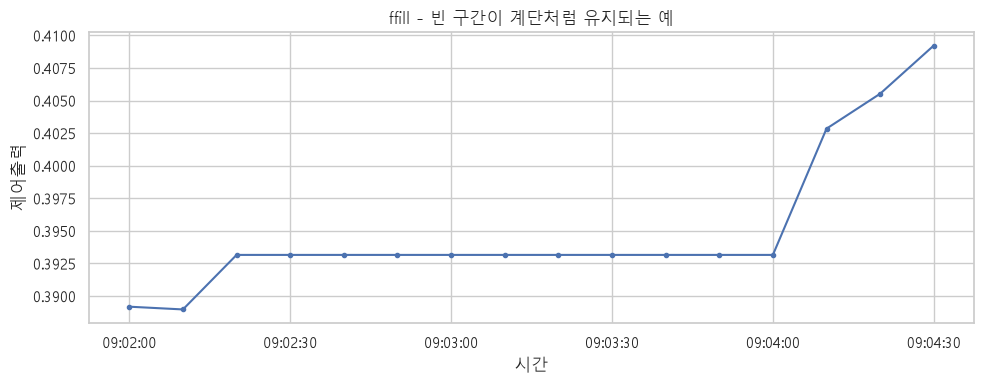

In [15]:
zoom_start = pd.Timestamp("2026-08-28 09:02:00")
zoom_end = pd.Timestamp("2026-08-28 09:04:30")

plt.figure(figsize=(10, 4))
plt.plot(
    ffill_control.loc[zoom_start:zoom_end].index,
    ffill_control.loc[zoom_start:zoom_end],
    marker="."
)
plt.title("ffill - 빈 구간이 계단처럼 유지되는 예")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.tight_layout()
plt.show()

# 12. 🌉 보간 — 앞뒤 실제값을 이용해 중간값 추정

보간은 한쪽 값을 그대로 복사하는 것이 아니라  
앞뒤 실제값을 이용해 빈 구간을 이어 줍니다.

### 적합한 경우
- 제어출력
- 온도
- 압력처럼 비교적 연속적으로 움직이는 센서
- 짧은 산발 결측

### 주의
보간으로 만든 값은 **실제 측정값이 아니라 추정값**입니다.

## 12-1. 선형 보간과 시간 보간의 차이

강의자료의 작은 예시를 그대로 실행해 봅니다.

시점:
- 09:00:00 → 10
- 09:00:10 → NaN
- 09:01:00 → 40

선형 보간은 **행 위치**를 기준으로 중간값 25를 만들고,  
시간 보간은 실제 시간 간격 비율을 반영해 15를 만듭니다.

In [16]:
tiny = pd.Series(
    [10.0, np.nan, 40.0],
    index=pd.to_datetime([
        "2026-08-28 09:00:00",
        "2026-08-28 09:00:10",
        "2026-08-28 09:01:00"
    ])
)

linear_value = tiny.interpolate(method="linear").iloc[1]
time_value = tiny.interpolate(method="time").iloc[1]

print("선형 보간:", linear_value)
print("시간 보간:", time_value)

선형 보간: 25.0
시간 보간: 15.0


## 12-2. 이미 10초 등간격으로 정규화했다면?

시간 간격이 모두 같은 격자에서는  
`linear`와 `time`이 같은 또는 거의 같은 결과를 낼 수 있습니다.

강의자료의 실습도 정규화된 등간격 데이터에서는 두 결과가 같다고 설명합니다.

In [17]:
linear_clean = as10.interpolate(method="linear")
time_clean = as10.interpolate(method="time")

difference = (linear_clean - time_clean).abs()

print("두 보간 결과의 최대 절대 차이:")
print(difference.max())

print("\n서로 다른 칸 수(아주 작은 부동소수점 오차 제외):")
print((difference > 1e-12).sum())

두 보간 결과의 최대 절대 차이:
제어출력     0.000000e+00
소입로온도    1.136868e-13
dtype: float64

서로 다른 칸 수(아주 작은 부동소수점 오차 제외):
제어출력     0
소입로온도    0
dtype: int64


## 12-3. 시간 보간 결과 그래프

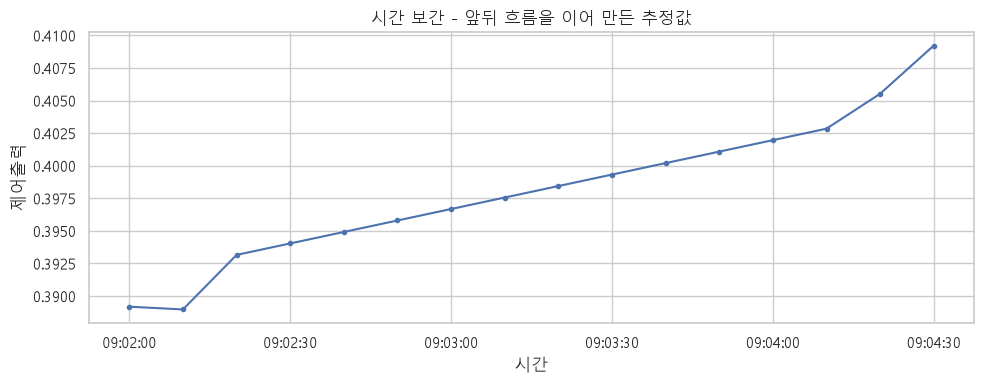

In [18]:
time_control = time_clean["제어출력"]

plt.figure(figsize=(10, 4))
plt.plot(
    time_control.loc[zoom_start:zoom_end].index,
    time_control.loc[zoom_start:zoom_end],
    marker="."
)
plt.title("시간 보간 - 앞뒤 흐름을 이어 만든 추정값")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.tight_layout()
plt.show()

# 13. 🚧 긴 연속 결측과 `limit`

긴 공백을 전부 직선으로 채우면 그 사이에 실제로 있었을:

- 급등
- 급락
- 이상 진동
- 설비 정지

를 지워 버릴 수 있습니다.

따라서 일정 길이 이상의 공백은 남겨 두고  
**짧은 구간만 제한적으로 보간**할 수 있습니다.

In [19]:
full_interp = as10["제어출력"].interpolate(method="time")

limited_interp = as10["제어출력"].interpolate(
    method="time",
    limit=2
)

print("제한 없이 보간 후 NaN:", int(full_interp.isna().sum()))
print("limit=2 보간 후 NaN:", int(limited_interp.isna().sum()))

제한 없이 보간 후 NaN: 0
limit=2 보간 후 NaN: 13


### `limit` 결과를 어떻게 읽을까?

`limit=2`는 연속 결측 구간에서 최대 2칸만 채웁니다.

따라서 남은 NaN은 “처리가 실패했다”기보다:

> **긴 공백은 과도하게 추정하지 않겠다는 의도적인 보수적 처리**

일 수 있습니다.

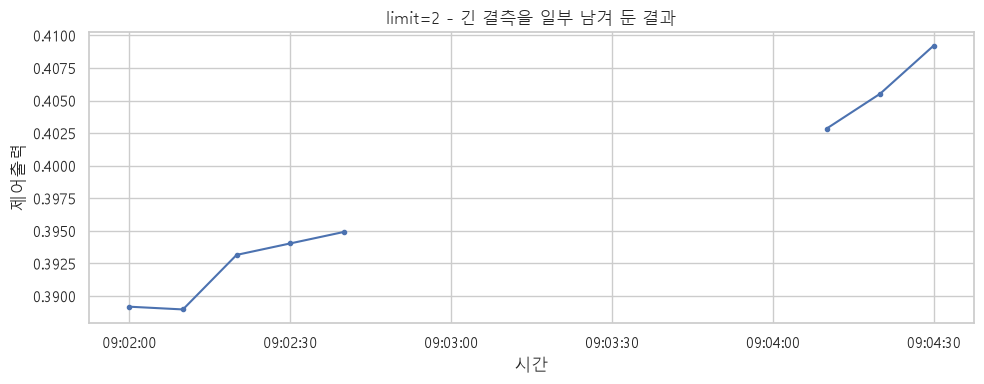

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(
    limited_interp.loc[zoom_start:zoom_end].index,
    limited_interp.loc[zoom_start:zoom_end],
    marker="."
)
plt.title("limit=2 - 긴 결측을 일부 남겨 둔 결과")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.tight_layout()
plt.show()

## 13-1. `limit_area`를 사용할 수 있는 상황

강의자료는 다음 옵션도 소개합니다.

```python
limit_area="inside"
```

- 양쪽에 실제값이 있는 **안쪽 공백**만 보간
- 데이터 맨 앞·맨 뒤처럼 한쪽 기준값이 없는 곳은 함부로 채우지 않음

예:

```python
clean = norm.interpolate(
    method="time",
    limit=2,
    limit_area="inside"
)
```

센서 시작·종료 구간의 결측까지 자동으로 만들어 내고 싶지 않을 때 유용합니다.

# 14. 🔴 실제 측정값과 보간값을 구분해서 보기

강의자료는 전후 그래프에서 **실제 측정값과 보간값을 구분**하는 것을 핵심 품질 점검으로 제시합니다.

아래에서는:
- 실제로 있던 값
- 보간으로 만들어진 값

을 서로 다른 마커로 표시합니다.

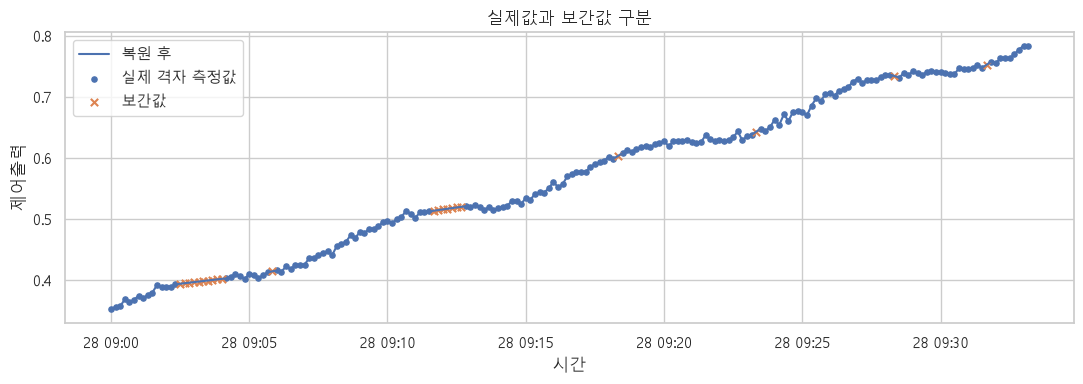

In [21]:
clean = as10.interpolate(method="time")
imputed_mask = as10["제어출력"].isna() & clean["제어출력"].notna()

plt.figure(figsize=(11, 4))

# 전체 복원선
plt.plot(clean.index, clean["제어출력"], label="복원 후")

# 실제 측정값
plt.scatter(
    as10.index[as10["제어출력"].notna()],
    as10.loc[as10["제어출력"].notna(), "제어출력"],
    s=14,
    label="실제 격자 측정값"
)

# 보간된 값
plt.scatter(
    clean.index[imputed_mask],
    clean.loc[imputed_mask, "제어출력"],
    marker="x",
    s=28,
    label="보간값"
)

plt.title("실제값과 보간값 구분")
plt.xlabel("시간")
plt.ylabel("제어출력")
plt.legend()
plt.tight_layout()
plt.show()

### 이 그래프에서 반드시 볼 것

1. 보간 구간이 지나치게 길지 않은가?
2. 보간값이 너무 매끈한 직선으로 긴 구간을 덮지 않는가?
3. 실제 측정값과 추정값을 나중에 구분할 수 있는가?

**그래프가 깨끗해졌다고 데이터가 실제로 복구된 것은 아닙니다.**

# 15. 🧭 상황에 맞는 결측 처리 코드

| 데이터 상황 | 더 자연스러운 시작점 | 이유 |
|---|---|---|
| 가동 모드·상태값 | `ffill(limit=...)` | 다음 변경 전까지 상태 유지가 자연스러울 수 있음 |
| 천천히 변하는 온도·압력 | `interpolate(method="time")` | 앞뒤 흐름과 시간 간격 반영 |
| 이미 완전히 등간격 정규화 | `interpolate()` | 선형과 시간 보간 결과가 거의 같을 수 있음 |
| 긴 연속 공백 | `interpolate(limit=...)` 또는 공백 유지 | 과도한 추정 방지 |
| 공백 자체가 설비 정지 정보 | 채우지 않기 | 누락 자체가 의미 있는 신호 |
| 결측 비율이 매우 높음 | 제외/센서 품질 검토 | 추정값이 실제값보다 많아질 위험 |
| 장기 추세용 다운샘플링 | `resample(...).mean()` | 노이즈 완화 |
| 피크 확인이 중요 | `resample(...).max()` 병행 | 평균에 묻히는 최대값 확인 |

> 마지막 두 줄은 분석 목적에 따른 추가 활용 예시입니다.  
> 어떤 집계가 “정답”인지는 센서 의미와 분석 목적에 따라 달라집니다.

## 15-1. 상태값이라면 무한정 ffill보다 `limit`을 고려

값이 며칠씩 비어 있는데 계속 앞값을 복사하면  
실제로 상태가 바뀌었어도 알아채기 어렵습니다.

짧은 공백까지만 유지하고 싶다면:

```python
filled = series.ffill(limit=2)
```

처럼 제한을 둘 수 있습니다.

이 코드는 강의자료의 “짧은 공백에 ffill”이라는 원칙을 코드로 더 보수적으로 적용한 예입니다.

# 16. ⚠️ `asfreq`를 쓸 때 원본을 따로 보관해야 하는 이유

`asfreq("10s")`는 **10초 격자에 정확히 맞는 시각의 값**을 배치합니다.

따라서 09:00:13처럼 격자와 어긋난 값은  
원본에는 존재하지만 `asfreq("10s")` 결과에는 그대로 나타나지 않을 수 있습니다.

그래서 실무에서는:

```python
raw = df.copy()
norm = raw.asfreq("10s")
```

처럼 원본을 유지하고 정규화 버전을 별도로 만드는 편이 좋습니다.

> `asfreq`를 썼다고 해서 원본 파일 자체를 삭제하거나 덮어쓰라는 뜻은 아닙니다.

# 17. 🔄 전처리 파이프라인 6단계

강의자료의 전체 흐름:

```text
1. 시간 인덱스
2. 간격 진단
3. 정규화
4. 결측 확인
5. 채우기
6. 재확인
```

순서가 중요한 이유는:

> **빈 칸을 먼저 드러낸 뒤 채워야 하기 때문**

입니다.

## 17-1. 재사용 가능한 파이프라인 함수

아래 함수는 학습용 예시입니다.

- 시간 인덱스 확인
- 지정 주기로 `asfreq`
- 처리 전 결측 출력
- 시간 보간
- 처리 후 결측 출력

을 한 번에 수행합니다.

In [22]:
def preprocess_continuous_sensor(
    df,
    columns,
    freq="10s",
    limit=None,
    keep_long_gaps=False
):
    data = df.copy().sort_index()

    # 정규화
    norm = data[columns].asfreq(freq)

    before = norm.isna().sum()

    # 긴 공백을 보호하고 싶으면 inside + limit 사용
    if keep_long_gaps:
        clean = norm.interpolate(
            method="time",
            limit=limit,
            limit_area="inside"
        )
    else:
        clean = norm.interpolate(
            method="time",
            limit=limit
        )

    after = clean.isna().sum()

    print("[처리 전 결측]")
    print(before)

    print("\n[처리 후 결측]")
    print(after)

    return norm, clean


norm_demo, clean_demo = preprocess_continuous_sensor(
    raw,
    ["제어출력", "소입로온도"],
    freq="10s"
)

[처리 전 결측]
제어출력     22
소입로온도    22
dtype: int64

[처리 후 결측]
제어출력     0
소입로온도    0
dtype: int64


# 18. 📋 시간축 품질 진단 리포트

전처리 전에 다음을 숫자로 남겨 두면 좋습니다.

- 측정 기간
- 원본 시점 수
- 기준 주기
- 정규화 후 시점 수
- 결측 개수
- 결측 비율
- 가장 긴 연속 결측

이 값들은 **보간된 데이터의 신뢰도를 해석하는 근거**가 됩니다.

In [23]:
def time_axis_report(norm_df):
    rows = []

    for col in norm_df.columns:
        runs = missing_run_lengths(norm_df[col])
        longest = int(runs.max()) if len(runs) else 0

        rows.append({
            "센서": col,
            "시점 수": len(norm_df),
            "결측 개수": int(norm_df[col].isna().sum()),
            "결측 비율": float(norm_df[col].isna().mean()),
            "최장 연속 결측": longest,
        })

    return pd.DataFrame(rows)


report = time_axis_report(as10)
display(report)

,센서,시점 수,결측 개수,결측 비율,최장 연속 결측
0,제어출력,200,22,0.11,10
1,소입로온도,200,22,0.11,10


# 19. ✅ 전처리 후 품질 점검 체크리스트

## ① 시간 간격
```python
clean.index.to_series().diff().value_counts()
```
모든 시점이 의도한 간격인지 확인

## ② 남은 NaN
```python
clean.isna().sum()
```
0개가 목표인지, 긴 공백을 일부러 남긴 것인지 확인

## ③ 추세 보존
전처리 전후 그래프 비교

## ④ 추정값 비율
전체 중 몇 %가 실제 측정이 아니라 보간값인지 기록

## ⑤ 긴 추정 구간
연속 결측이 길었던 구간을 별도로 표시

> **NaN이 0개라는 사실만으로 전처리가 잘됐다고 판단하면 안 됩니다.**

In [ ]:
# 실제 격자값이 없어서 보간된 비율
imputed_ratio = imputed_mask.mean()

print("제어출력 보간 비율:", f"{imputed_ratio:.1%}")

제어출력 보간 비율: 11.0%


# 20. 🌳 빠른 선택 의사결정

```text
Q1. 시간을 더 촘촘하게 만들려는가?
 ├─ YES → asfreq로 격자 생성
 │        ↓
 │        결측 위치 확인
 │        ↓
 │        상태값? → ffill
 │        연속형? → interpolate
 │        긴 공백? → limit / 공백 유지
 │
 └─ NO
      ↓
Q2. 여러 값을 더 큰 시간 단위로 요약하려는가?
 ├─ YES → resample
 │        ├─ 일반 수준 → mean
 │        ├─ 최대 피크 → max
 │        └─ 필요하면 둘 다 비교
 │
 └─ NO → 원본 주기 유지
```

# 21. 📂 실제 강의 CSV에 적용할 때의 기본 템플릿

이번에 첨부된 파일은 PDF 강의자료이고 실제 `equipment_sensor.csv`는 포함되어 있지 않습니다.  
따라서 아래 코드는 **실제 CSV가 있을 때 실행하는 템플릿**입니다.

In [ ]:
# 실제 강의 CSV가 있을 때 사용
#
# import pandas as pd
# import matplotlib.pyplot as plt
#
# df = pd.read_csv("equipment_sensor.csv")
# df["timestamp"] = pd.to_datetime(df["timestamp"])
# df = df.set_index("timestamp").sort_index()
#
# # 1. 측정 간격 진단
# sec = df.index.to_series().diff().dt.total_seconds()
# print(sec.value_counts().sort_index())
#
# # 2. 10초 정규화
# norm = df[["제어출력", "소입로온도"]].asfreq("10s")
#
# # 3. 결측 진단
# print(norm.isna().sum())
# print(norm.isna().mean())
#
# # 4. 연속형 센서 시간 보간
# clean = norm.interpolate(method="time")
#
# # 5. 처리 후 확인
# print(clean.isna().sum())

# 22. ⚡ 시험/실무 핵심 포인트 & 오해하기 쉬운 점

### ① `sort_index()`와 규칙적 주기는 다름
정렬됐어도 간격은 10초·13초·70초일 수 있습니다.

### ② 리샘플링 후 NaN은 에러가 아님
원래 비어 있던 시점을 격자 위에서 드러낸 정보입니다.

### ③ `asfreq`와 `resample`은 같은 기능이 아님
- asfreq → 격자에 배치
- resample → 구간을 묶어 집계

### ④ 다운샘플링에 `asfreq`를 쓰면 값을 많이 버릴 수 있음
여러 값을 합쳐야 하면 `resample`이 자연스럽습니다.

### ⑤ `dropna()`로 빈 행을 지우면 시간 간격이 다시 불규칙해질 수 있음

### ⑥ `ffill`은 변화하는 센서를 계단처럼 만들 수 있음

### ⑦ 불규칙 시각에서 선형 보간은 시간 간격을 무시할 수 있음
DatetimeIndex가 있다면 `method="time"`을 고려합니다.

### ⑧ 이미 등간격이라면 linear와 time이 거의 같을 수 있음

### ⑨ 긴 결측을 전부 보간하면 고장 신호를 매끈하게 지울 수 있음
`limit` 또는 공백 유지 검토

### ⑩ 실제값과 추정값은 구분해서 관리
보간 후 NaN 0은 “실제 데이터 복구 완료”와 같은 말이 아닙니다.

# 23. 🧠 마지막 암기 카드

```text
시간 준비
to_datetime
→ set_index
→ sort_index

주기 진단
index.to_series()
→ diff()
→ total_seconds()
→ value_counts()

촘촘하게
→ asfreq

듬성하게 요약
→ resample + mean/max

결측 점검
개수 → 비율 → 위치 → 연속 길이

상태값
→ ffill / bfill

연속형 센서
→ interpolate

불규칙 간격
→ method="time"

긴 공백
→ limit / limit_area / 남겨두기

전처리 순서
정규화
→ 결측 확인
→ 채우기
→ 재확인
→ 그래프 검증
```

# 24. 🔍 1분 셀프 체크 퀴즈

### Q1.
1초 센서 데이터를 1분 평균으로 줄이고 싶습니다.  
`asfreq("1min")`과 `resample("1min").mean()` 중 어느 쪽이 적합할까요?

**정답:** `resample("1min").mean()`  
**해설:** 1분 안의 여러 값을 합쳐 대표값을 만들어야 하기 때문입니다.

---

### Q2.
온도 센서가 10초 격자로 정규화된 뒤 한두 칸씩 비어 있습니다.  
값이 부드럽게 변한다면 어떤 방법이 자연스러운 시작점일까요?

**정답:** `interpolate(method="time")` 또는 등간격이라면 기본 선형 보간  
**해설:** 앞뒤 실제값의 흐름을 이용해 중간값을 추정합니다.

---

### Q3.
보간 후 NaN이 0개입니다. 이것만으로 전처리가 완벽하다고 할 수 있을까요?

**정답:** 아니요.  
**해설:** 긴 공백까지 모두 추정했을 수 있으므로 실제값/보간값 구분, 긴 연속 결측, 전후 그래프를 함께 봐야 합니다.

# 25. 🎯 초급 실습 과제

합성 데이터 `raw`를 이용해 직접 해보세요.

1. 측정 간격의 최빈값과 최대값을 출력
2. `asfreq("10s")`와 `resample("10s").mean()`의 결측 개수 비교
3. 결측 비율 계산
4. 첫 번째 결측 시각 출력
5. 가장 긴 연속 결측 길이 계산
6. `ffill()`과 `interpolate(method="time")` 결과 그래프 비교
7. `limit=2` 적용 후 남은 NaN 개수 확인
8. 1분 단위 `mean`과 `max`를 함께 계산
9. 실제값과 보간값의 비율을 리포트로 출력
10. “이 데이터는 어느 방식으로 처리하는 것이 더 적합한가?”를 2~3문장으로 설명